In [1]:
from pathlib import Path

import cv2
import numpy as np

from draftslice.core.io import load_image
from draftslice.core.types import Mat

files = sorted(Path("../data/images").glob("*.jpg"))

In [2]:
import ipywidgets as widgets
from IPython.display import display
from matplotlib import pyplot as plt

file_names = [f.name for f in files]


def _view_img(filename: str):

    path = next(f for f in files if f.name == filename)
    img = load_image(str(path))
    plt.figure(figsize=(16, 8))
    plt.imshow(img)
    plt.title(img.shape)
    plt.axis("off")
    plt.show()
    return img


ui = widgets.interactive(_view_img, filename=file_names)
display(ui)

interactive(children=(Dropdown(description='filename', options=('1.jpg', '10.jpg', '11.jpg', '12.jpg', '13.jpg…

scale=2 - w=1475, h=919


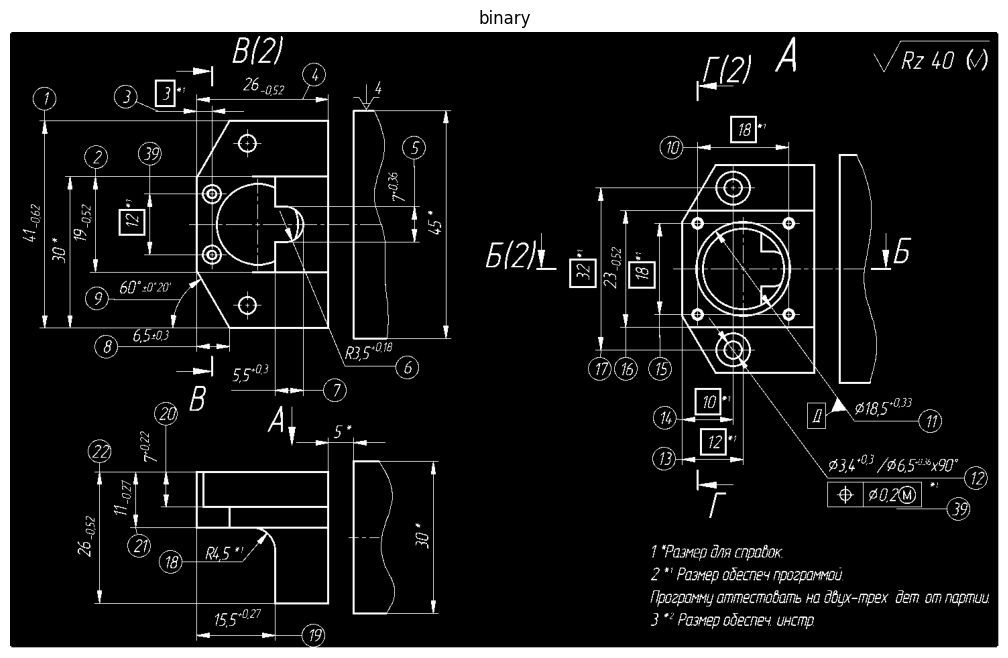

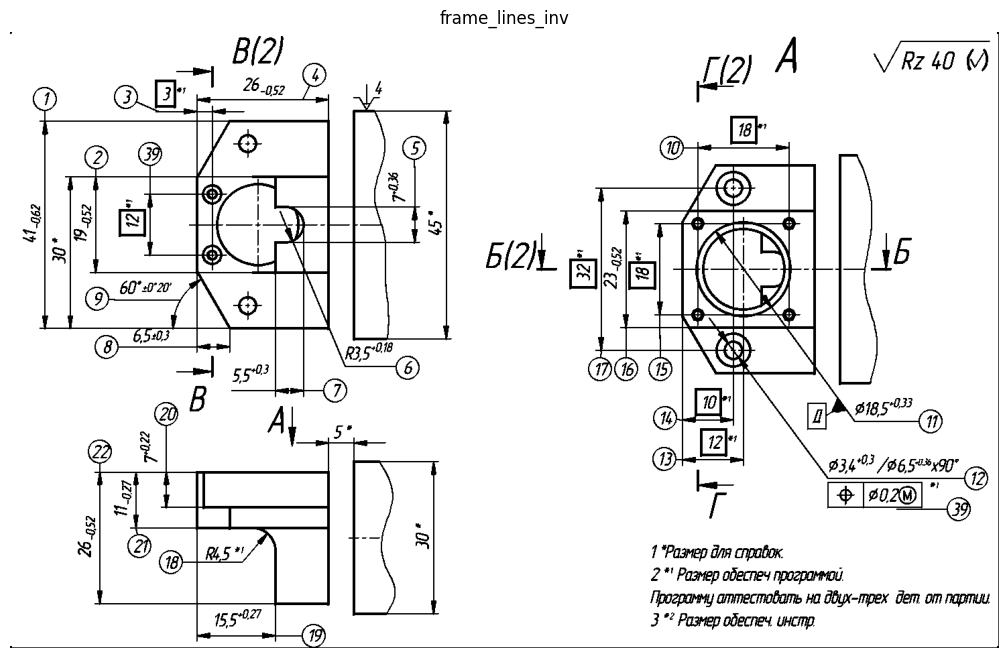

In [52]:
img: Mat = np.array(ui.result, dtype=np.uint8)

gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
# blurred = cv2.GaussianBlur(gray, (3, 3), 0)
binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
h, w = binary.shape[:2]


scale = w // 500
print(f"scale={scale} - w={w}, h={h}")

k_h = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (1, w // 100))
k_v = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (w // 100, 1))
morph_opening_h = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k_h)
morph_opening_v = cv2.morphologyEx(binary, cv2.MORPH_OPEN, k_v)
mask = cv2.bitwise_or(morph_opening_h, morph_opening_v)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (scale, scale))
dilated = cv2.dilate(mask, kernel, iterations=1)

dilated_inv = cv2.bitwise_not(dilated)

plt.figure(figsize=(16, 8))
plt.imshow(binary, cmap="gray")
plt.title("binary")
plt.axis("off")
plt.show()

plt.figure(figsize=(16, 8))
plt.imshow(dilated_inv, cmap="gray")
plt.title("frame_lines_inv")
plt.axis("off")
plt.show()


In [20]:
from dataclasses import dataclass


@dataclass(frozen=True)
class ConnectedComponentsResult:
    filled: Mat
    labels: Mat
    stats: np.ndarray
    centroids: np.ndarray
    contours: np.ndarray


def _fill_contours(shape: tuple[int, int], contours: tuple[Mat, ...], indices: np.ndarray) -> Mat:
    filled = np.zeros(shape, dtype=np.uint8)
    for i in indices:
        cv2.drawContours(filled, contours, int(i), 255, cv2.FILLED)
    return filled


def find_connected_components(binary: Mat) -> ConnectedComponentsResult:
    contours, hierarchy = cv2.findContours(binary, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    outer_indices = np.flatnonzero(hierarchy[0][:, 3] == -1)

    filled = _fill_contours(binary.shape, contours, outer_indices)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(filled, connectivity=8)

    result_contours = np.empty(num_labels - 1, dtype=object)
    for i in outer_indices:
        x, y = contours[i][0, 0]
        label = labels[y, x]
        result_contours[label - 1] = contours[i].reshape(-1, 2)

    print(f"components={num_labels - 1}")
    return ConnectedComponentsResult(
        filled=filled, labels=labels, stats=stats[1:], centroids=centroids[1:], contours=result_contours
    )

In [5]:
def run_find_connected_components(img: Mat, binary: Mat) -> ConnectedComponentsResult:
    result = find_connected_components(binary)

    plt.figure(figsize=(16, 8))
    plt.imshow(result.filled, cmap="gray")
    plt.title("filled")
    plt.axis("off")
    plt.show()

    cmap = plt.get_cmap("tab20")
    vis = img.copy()
    for i in range(len(result.stats)):
        label = i + 1
        color = np.array(cmap(i % 20)[:3]) * 255
        mask = result.labels == label
        vis[mask] = (vis[mask] * 0.5 + color * 0.5).astype(np.uint8)

    plt.figure(figsize=(16, 8))
    plt.imshow(vis)
    plt.title(f"components={len(result.stats)}")
    plt.axis("off")
    plt.show()
    return result

components=155


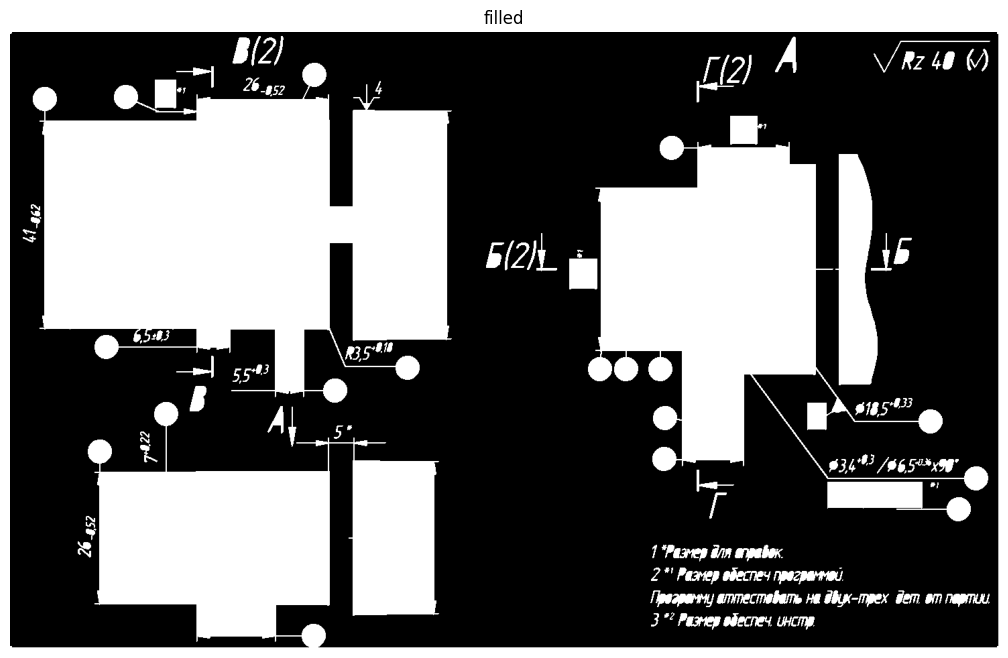

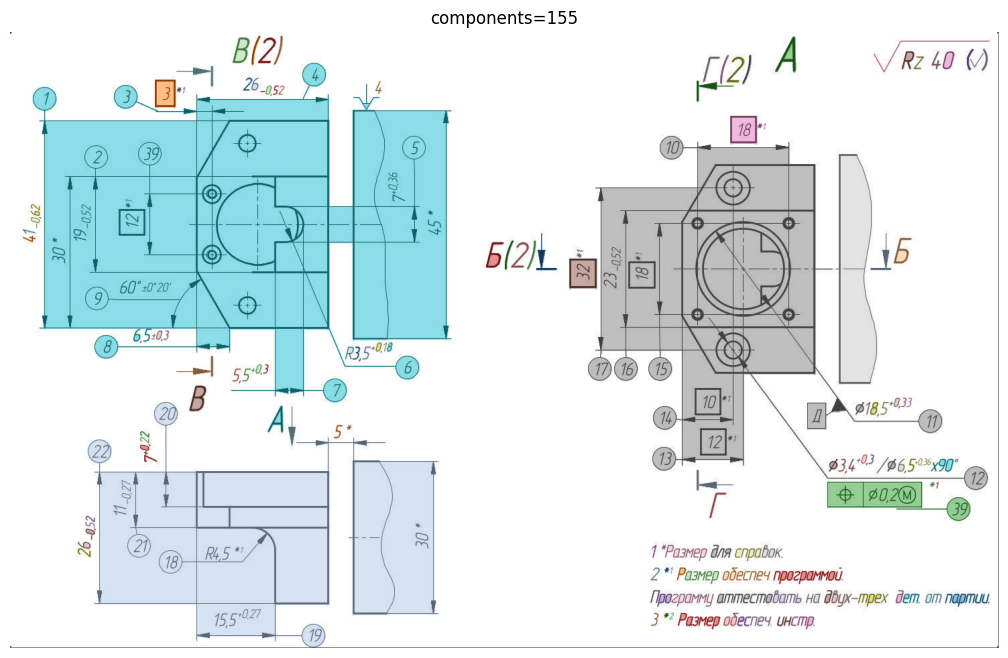

In [46]:
components_result = run_find_connected_components(img, dilated)

In [47]:
areas = components_result.stats[:, cv2.CC_STAT_AREA]
x1 = components_result.stats[:, cv2.CC_STAT_LEFT]
y1 = components_result.stats[:, cv2.CC_STAT_TOP]
w = components_result.stats[:, cv2.CC_STAT_WIDTH]
h = components_result.stats[:, cv2.CC_STAT_HEIGHT]
x2 = x1 + w
y2 = y1 + h
n = len(areas)

img_h, img_w = img.shape[:2]
touches_edge = (x1 <= 0) | (y1 <= 0) | (x2 >= img_w) | (y2 >= img_h)

mean_area = np.mean(areas)
small = np.flatnonzero((areas < mean_area) & ~touches_edge) + 1
seed_labels = np.flatnonzero((areas >= mean_area) & ~touches_edge) + 1
edge_labels = np.flatnonzero(touches_edge) + 1

print(f"components={n}, small={len(small)}, seeds={len(seed_labels)}, edge={len(edge_labels)}")

components=155, small=149, seeds=4, edge=2


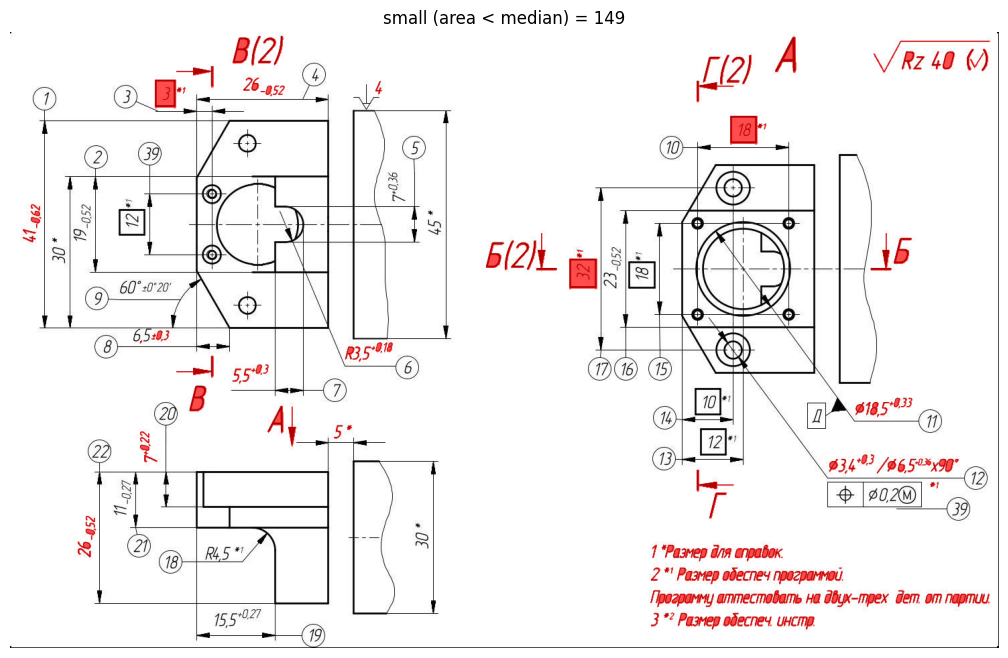

In [48]:
small_mask = np.isin(components_result.labels, small)

vis = img.copy()
vis[small_mask] = (vis[small_mask] * 0.3 + np.array([255, 0, 0]) * 0.7).astype(np.uint8)

plt.figure(figsize=(16, 8))
plt.imshow(vis)
plt.title(f"small (area < median) = {len(small)}")
plt.axis("off")
plt.show()

In [49]:
chunk_parent = np.arange(n + 1)


def chunk_find(label: int) -> int:
    while chunk_parent[label] != label:
        chunk_parent[label] = chunk_parent[chunk_parent[label]]
        label = chunk_parent[label]
    return label


for a_idx in range(len(small)):
    for b_idx in range(a_idx + 1, len(small)):
        a, b = int(small[a_idx]), int(small[b_idx])
        i, j = a - 1, b - 1
        overlap_x = max(x1[i], x1[j]) < min(x2[i], x2[j])
        overlap_y = max(y1[i], y1[j]) < min(y2[i], y2[j])
        gap_x = max(x1[i], x1[j]) - min(x2[i], x2[j])
        gap_y = max(y1[i], y1[j]) - min(y2[i], y2[j])
        same_row = overlap_y and gap_x <= (w[i] + w[j]) / 2
        same_col = overlap_x and gap_y <= (h[i] + h[j]) / 2
        if same_row or same_col:
            ra, rb = chunk_find(a), chunk_find(b)
            if ra != rb:
                chunk_parent[ra] = rb

chunk_id = np.arange(n + 1)
chunk_id[small] = np.array([chunk_find(label) for label in small])
chunk_id[edge_labels] = 0
merged_labels = chunk_id[components_result.labels]

print(f"small={len(small)}, chunks={len(np.unique(chunk_id[small]))}")

small=149, chunks=22


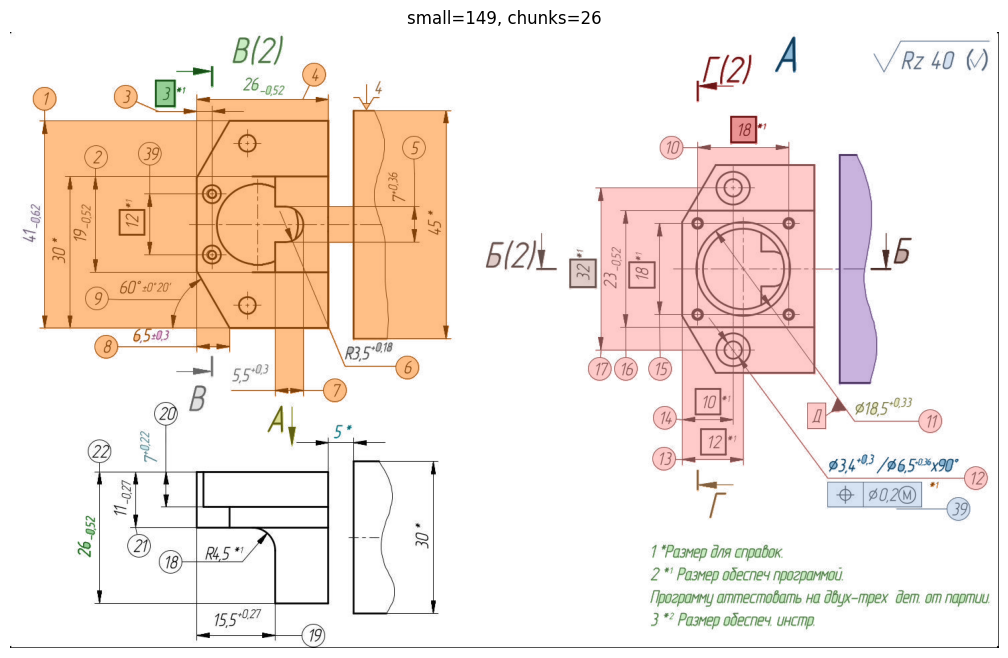

In [50]:
unique_chunks = np.unique(merged_labels)
unique_chunks = unique_chunks[unique_chunks != 0]

cmap = plt.get_cmap("tab20")
vis = img.copy()

for i, chunk in enumerate(unique_chunks):
    color = np.array(cmap(i % 20)[:3]) * 255
    mask = merged_labels == chunk
    vis[mask] = (vis[mask] * 0.5 + color * 0.5).astype(np.uint8)

plt.figure(figsize=(16, 8))
plt.imshow(vis)
plt.title(f"small={len(small)}, chunks={len(unique_chunks)}")
plt.axis("off")
plt.show()

In [26]:
from scipy.ndimage import distance_transform_edt

unique_labels = np.unique(merged_labels)
unique_labels = unique_labels[unique_labels != 0]

is_seed_lookup = np.zeros(n + 1, dtype=bool)
is_seed_lookup[seed_labels] = True
markers = np.where(is_seed_lookup[merged_labels], merged_labels, 0)

_, indices = distance_transform_edt(markers == 0, return_indices=True)
nearest_marker = markers[indices[0], indices[1]]

groups = np.zeros(n + 1, dtype=np.int32)
groups[seed_labels] = seed_labels
for label in unique_labels:
    if is_seed_lookup[label]:
        continue
    votes = nearest_marker[merged_labels == label]
    groups[label] = np.bincount(votes).argmax()

print(f"seeds={len(seed_labels)}, groups={len(np.unique(groups[unique_labels]))}")

seeds=6, groups=6


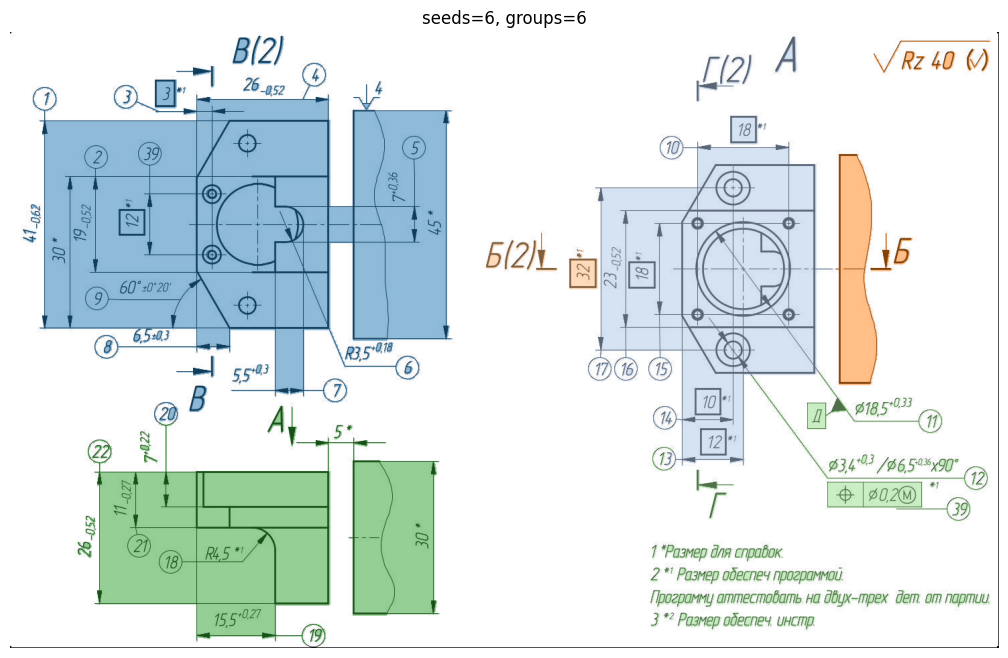

In [27]:
group_image = groups[merged_labels]
unique_groups = np.unique(group_image)
unique_groups = unique_groups[unique_groups != 0]

cmap = plt.get_cmap("tab20")
vis = img.copy()
for i, group in enumerate(unique_groups):
    color = np.array(cmap(i % 20)[:3]) * 255
    mask = group_image == group
    vis[mask] = (vis[mask] * 0.5 + color * 0.5).astype(np.uint8)

plt.figure(figsize=(16, 8))
plt.imshow(vis)
plt.title(f"seeds={len(seed_labels)}, groups={len(unique_groups)}")
plt.axis("off")
plt.show()

In [28]:
@dataclass(frozen=True)
class RegionCrop:
    group_label: int
    image: Mat
    left: int
    top: int
    width: int
    height: int


def extract_region_crops(img: Mat, group_image: np.ndarray) -> list[RegionCrop]:
    crops = []
    unique_groups = np.unique(group_image)
    unique_groups = unique_groups[unique_groups != 0]
    for label in unique_groups:
        ys, xs = np.nonzero(group_image == label)
        top, left = int(ys.min()), int(xs.min())
        bottom, right = int(ys.max()) + 1, int(xs.max()) + 1

        crop = img[top:bottom, left:right].copy()
        group_crop = group_image[top:bottom, left:right]
        foreign_mask = (group_crop != label) & (group_crop != 0)
        crop[foreign_mask] = 255

        crops.append(
            RegionCrop(group_label=int(label), image=crop, left=left, top=top, width=right - left, height=bottom - top)
        )
    return crops


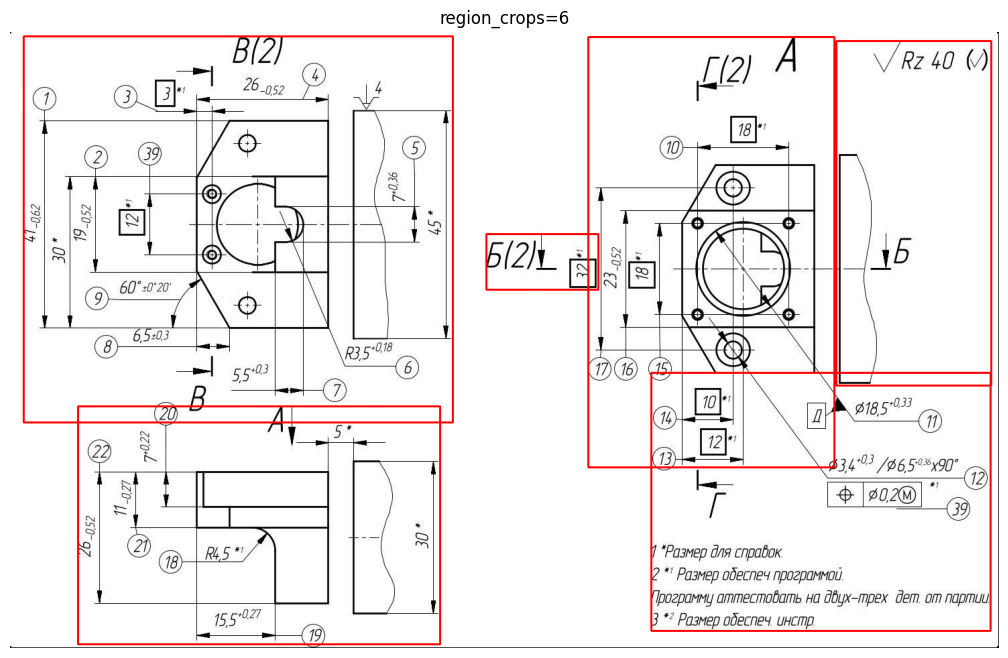

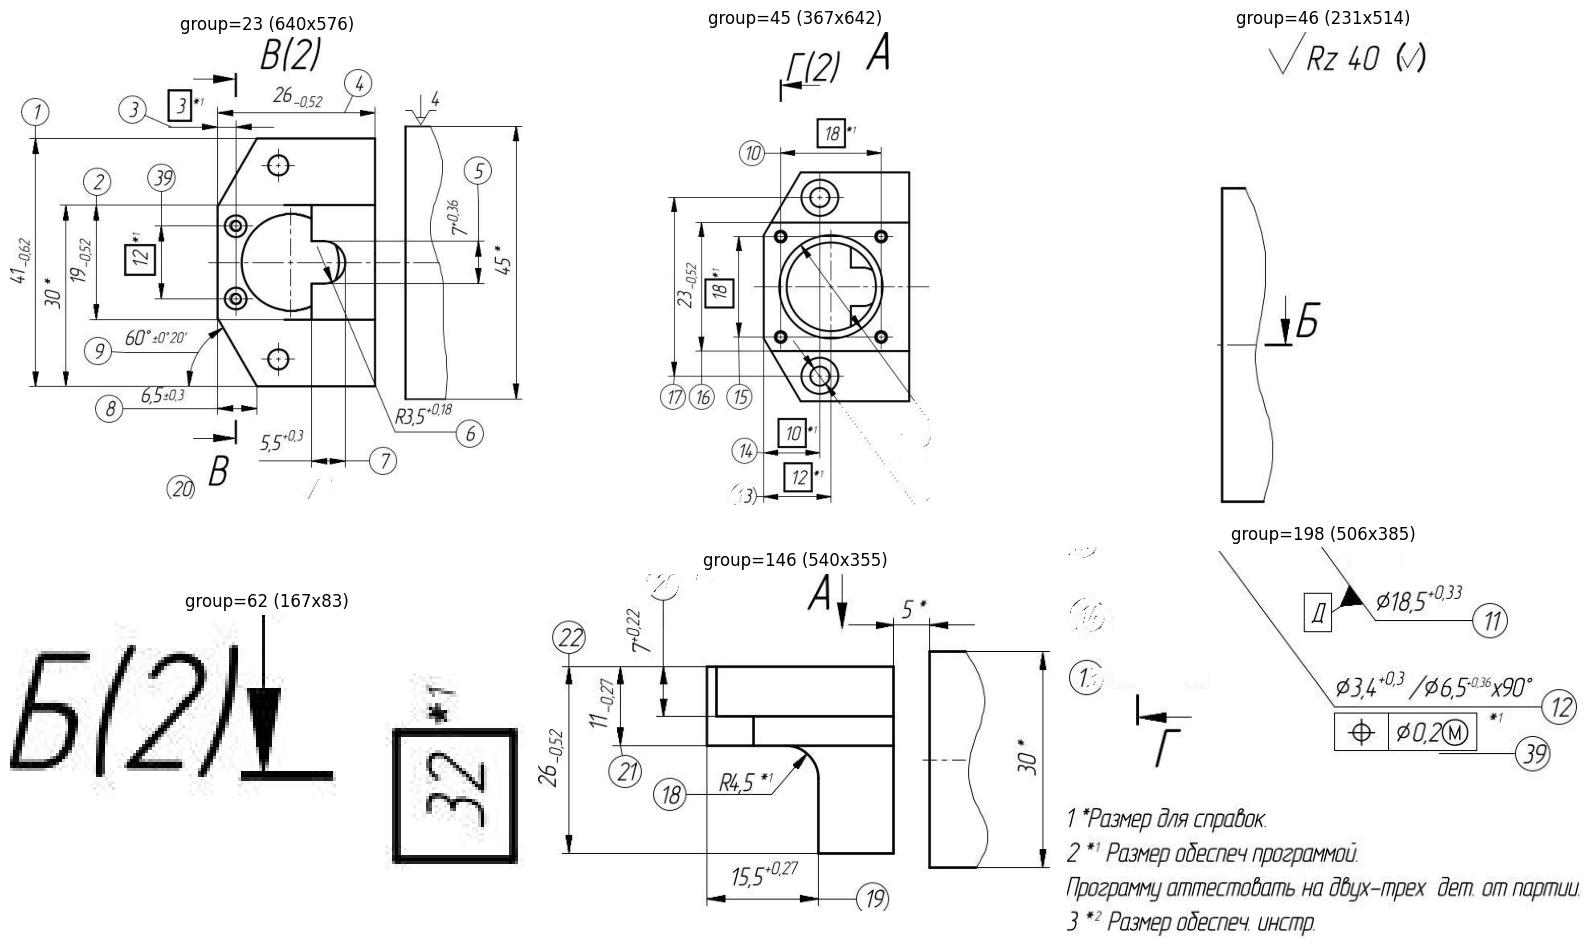

In [29]:
region_crops = extract_region_crops(img, group_image)

vis = img.copy()
box_thickness = max(2, img.shape[1] // 500)
for crop in region_crops:
    cv2.rectangle(
        vis, (crop.left, crop.top), (crop.left + crop.width, crop.top + crop.height), (255, 0, 0), box_thickness
    )

plt.figure(figsize=(16, 8))
plt.imshow(vis)
plt.title(f"region_crops={len(region_crops)}")
plt.axis("off")
plt.show()

cols = min(3, len(region_crops))
rows = (len(region_crops) + cols - 1) // cols
plt.figure(figsize=(16, 5 * rows))
for i, crop in enumerate(region_crops):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(crop.image)
    plt.title(f"group={crop.group_label} ({crop.width}x{crop.height})")
    plt.axis("off")
plt.tight_layout()
plt.show()
